In [1]:
using Piccolo
using CairoMakie

In [6]:
using QuantumToolbox
using DifferentialEquations

## Defining Rho dot

In [3]:
σ_ = ComplexF64[0 1; 0 0]
σz = ComplexF64[1 0; 0 -1]

function Commutator(H, ρ)
    return H * ρ - ρ * H
end

function Anti_Commutator(H, ρ)
    return H * ρ + ρ * H
end

function inner_D(ρ, σ)
    return σ * ρ * σ' - 0.5 * Anti_Commutator(σ' * σ, ρ)
end

function D_1(ρ, T1::Real, σ)
    return 1/T1 * inner_D(ρ, σ)
end

function D_ϕ(ρ, Tϕ::Real, σ)
    return 1/(2* Tϕ) * inner_D(ρ, σ)
end

# function ρ̇!1(H, ρ)
#     return (- im * Commutator(H, ρ) + D_1(ρ, T1, σ_) + D_ϕ(ρ, Tϕ, σz))
# end

# function Hamiltonian(t, Tg; N = 100)
#     H0 = ComplexF64[0 0; 0 0]
    
#     function gaussian_curve(t, Tg, N)
#         Ω0 = π / (Tg * (super_duper_value - ℯ^(-2))) / 2
#         μ = Tg / 2
#         σ = Tg / 4
#         return Ω0 * (ℯ .^ (-(t .- μ) .^2 / (2σ^2)) .- ℯ .^ (-2))
#     end

#     return  H0 .+ gaussian_curve(t, Tg, N) .* σx / 2
# end

D_ϕ (generic function with 1 method)

In [ ]:
σ_ = ComplexF64[0 1; 0 0]
σx = ComplexF64[0 1; 1 0] 
σz = ComplexF64[1 0; 0 -1]

const super_duper_value = 0.598144006661 # integral from -1/2 to 1/2 of e^(-8u^2)

function gaussian_curve(t, Tg, N)
    Ω0 = π / (Tg * (super_duper_value - ℯ^(-2))) / 2
    μ = Tg / 2
    σ = Tg / 4
    return Ω0 * (ℯ .^ (-(t .- μ) .^2 / (2σ^2)) .- ℯ .^ (-2))
end

function Hamiltonian(t, Tg; N = 100)
    H0 = ComplexF64[0 0; 0 0]
    return  H0 .+ gaussian_curve(t, Tg, N) .* σx # / 2
end

function ρ̇!(drho, rho, p, t)
    H = Hamiltonian(t, Tg)
    drho .= (- im * Commutator(H, rho) + D_1(rho, T1, σ_) + D_ϕ(rho, Tϕ, σz))
end

ρ̇! (generic function with 1 method)

## Main code base(Small scale)

In [36]:
T1 = 150 * 10
Tϕ = 100 * 10
initial_state = ComplexF64[1; 0]
ρ0 = initial_state * initial_state'
Tg = 10
function solving(time, chooser)
    t_span = (0.0, time)
    prob = ODEProblem(ρ̇!, ρ0,adaptive=false, t_span)
    sol = solve(prob, Tsit5(), dt=0.1)
    states = sol.u
    if chooser == 0
        return states

    elseif chooser == 1
        populations = []
        for i in range(1, size(states)[1])
            push!(populations, real(initial_state' * states[i] * initial_state))
            end
        return populations
        
    elseif chooser == 2 
        fidelities = []
        for i in range(1, size(states)[1])
            push!(fidelities, real(Uhlmann_Fidelity(target_ρ, states[i])))
            end
        return fidelities
    end
end

function Uhlmann_Fidelity(ρ_target, ρ_final)
    (tr(sqrt(sqrt(ρ_target) * ρ_final * sqrt(ρ_target))))^2
end

target_state = ComplexF64[0; 1]
target_ρ = target_state * target_state'


2×2 Matrix{ComplexF64}:
 0.0+0.0im  0.0+0.0im
 0.0+0.0im  1.0+0.0im

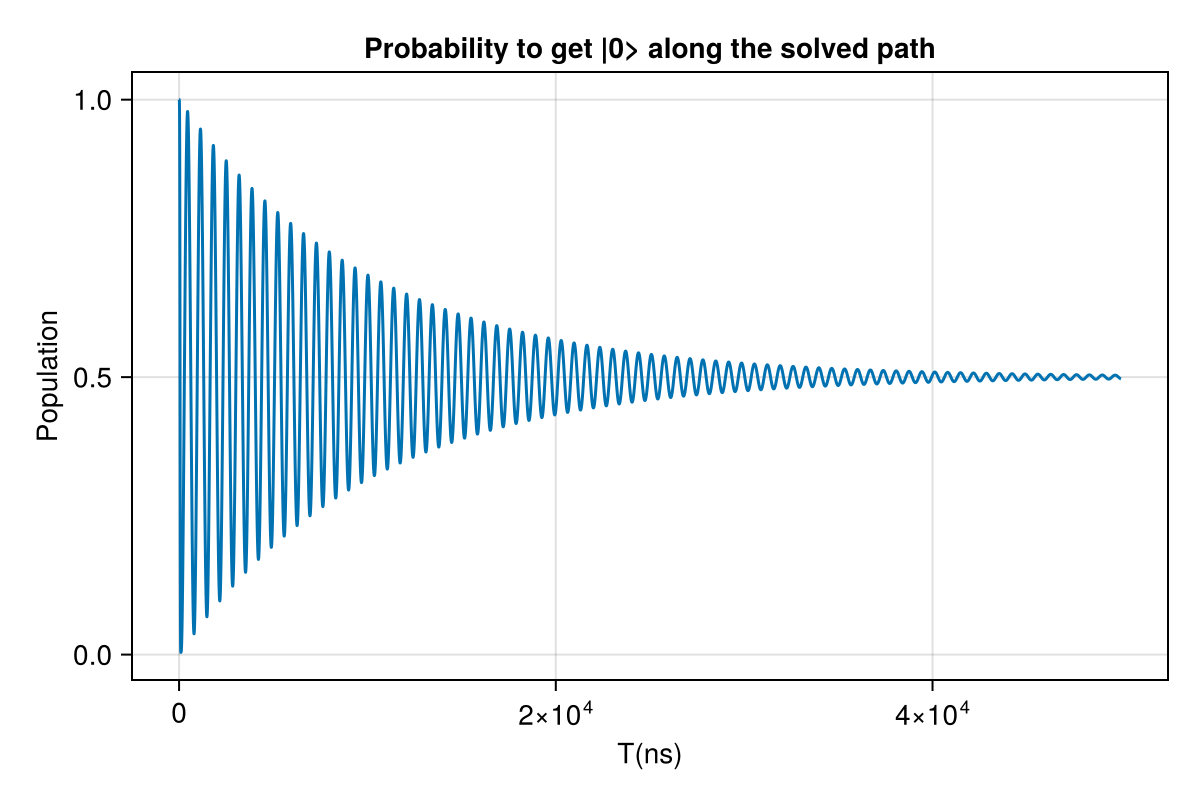

CairoMakie.Screen{IMAGE}


In [37]:
small_sol = solving(0.5 * 10^4, 1)
fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Probability to get |0> along the solved path", xlabel = "T(ns)", ylabel = "Population")
lines!(ax, small_sol)
display(fig)

## Large Scale

In [38]:
T1 = 150 * 10^3
Tϕ = 100 * 10^3
large_scale = solving(10^6, 1)

┌ Warning: Verbosity toggle: max_iters 
│  Interrupted. Larger maxiters is needed. If you are using an integrator for non-stiff ODEs or an automatic switching algorithm (the default), you may want to consider using a method for stiff equations. See the solver pages for more details (e.g. https://docs.sciml.ai/DiffEqDocs/stable/solvers/ode_solve/#Stiff-Problems).
└ @ SciMLBase /Users/bordeim1/.julia/packages/SciMLBase/zPFdK/src/integrator_interface.jl:963


1000001-element Vector{Any}:
 1.0
 0.9999999648690523
 0.9999994152213426
 0.9999969211116619
 0.9999898835615932
 0.9999743331198273
 0.9999447140087167
 0.9998936553371478
 0.9998117314244137
 0.999687213911826
 ⋮
 0.3312449770232124
 0.3305799036874243
 0.329929129843303
 0.32929271038412405
 0.3286706989916187
 0.3280631481314464
 0.3274701090487689
 0.3268916317639282
 0.3263277650682276

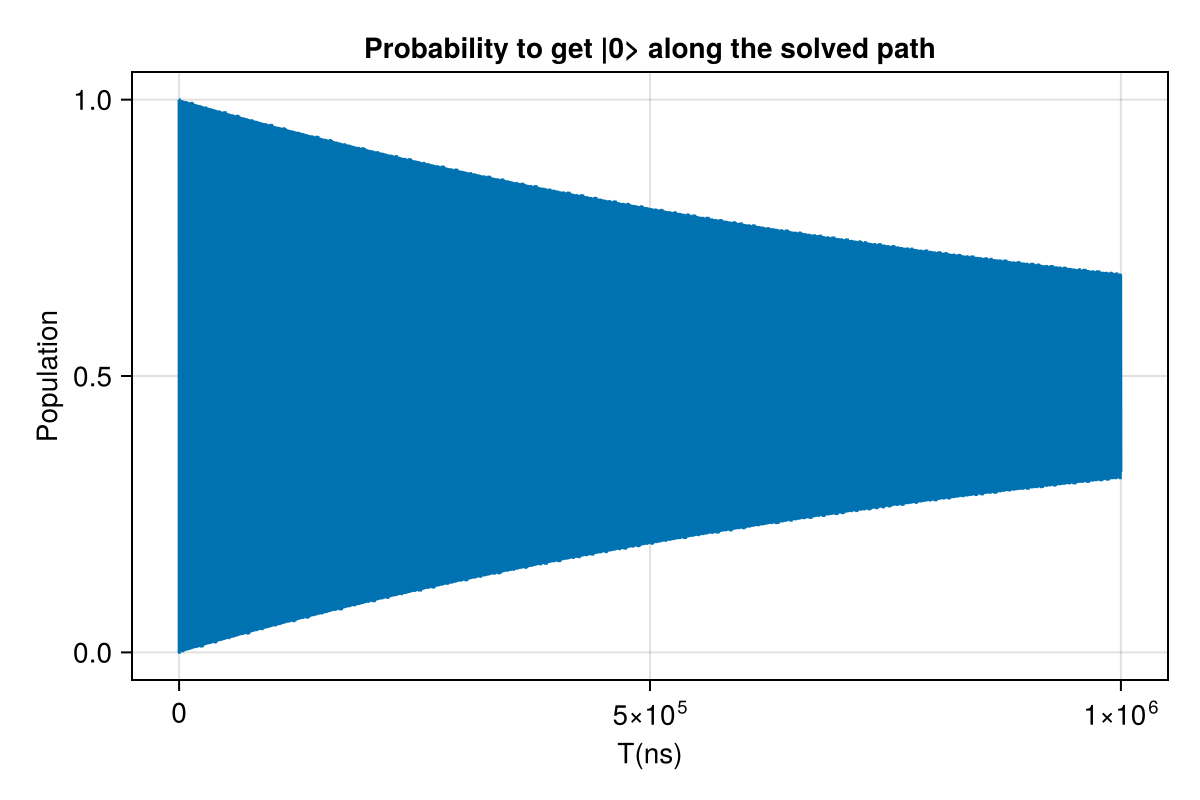

CairoMakie.Screen{IMAGE}


In [39]:
fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Probability to get |0> along the solved path", xlabel = "T(ns)", ylabel = "Population")
lines!(ax, large_scale)
display(fig)

In [ ]:
# Tg_range = range(1, 30)
# function solver()
#     states = []
#     for i in Tg_range
#         t_span = (0.0, i)
#         prob = ODEProblem(ρ̇!, ρ0, t_span)
#         sol = solve(prob, Tsit5(), dt=0.05)
#         final = sol.u[end]
#         push!(states, sol.u)
#     end
#     return states
# end


# mega_populations = []
# for i in range(1, size(solver())[1])
#     inner = []
#     for j in range(1, size(solver()[i])[1])
#         push!(inner, real(initial_state' * solver()[i][j] * initial_state))
#     end
#     push!(mega_populations, inner)
# end

# mega_infidelity = []
# for i in range(1, size(solver())[1])
#     inner = []
#     for j in range(1, size(solver()[i])[1])
#         push!(inner, real(Uhlmann_Fidelity(target_ρ, solver()[i][j])))
#     end
#     push!(mega_infidelity, inner)
# end
# #mega_infidelity

In [173]:
# fig = Figure(size = (600, 400))
# ax = Axis(fig[1, 1], title = "Probability to get |0> along the solved path", xlabel = "T(ns)", ylabel = "Population")
# for i in range(1, size(mega_populations)[1])
#     lines!(ax, mega_populations[i])
# end
# display(fig)

In [174]:
# fig = Figure(size = (600, 400))
# ax = Axis(fig[1, 1], title = "Probability to get |0> along the solved path", xlabel = "T(ns)", ylabel = "Population")
# for i in range(1, size(mega_infidelity)[1])
#     lines!(ax, mega_infidelity[i])
# end
# display(fig)